In [1]:
import os
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import cupy as cp
import cudf
from cuml.manifold import TSNE
import matplotlib.pyplot as plt

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour
)

optuna.logging.set_verbosity(optuna.logging.INFO)
seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)
os.environ["CC"] = "/usr/bin/gcc"
torch.set_float32_matmul_precision('high')



In [2]:
class PrecomputedTripletDataset(torch.utils.data.Dataset):
    def __init__(self, X, phys, pos_indices, neg_indices):
        """
        X: tenseur [N, D] des features chimiques (sur CPU)
        phys: tenseur [N, n_phys] des valeurs physiques (sur CPU)
        pos_indices, neg_indices: listes d'indices pré-calculés
        """
        # Transférer les tenseurs sur GPU une seule fois ici
        self.X = X.cuda()
        self.phys = phys.cuda()
        self.pos_indices = pos_indices
        self.neg_indices = neg_indices

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        anchor_x = self.X[idx]
        anchor_phys = self.phys[idx]
        pos_idx = int(self.pos_indices[idx])
        neg_idx = int(self.neg_indices[idx])
        positive_x = self.X[pos_idx]
        positive_phys = self.phys[pos_idx]
        negative_x = self.X[neg_idx]
        negative_phys = self.phys[neg_idx]
        return anchor_x, positive_x, negative_x, anchor_phys, positive_phys, negative_phys


In [3]:
# Définir les colonnes physiques utilisées
phys_columns = ["TEFF", "LOGG", "J", "H", "K"]


train_df = pd.read_csv('../../../data/train_resample_minmax_all.csv')
test_df = pd.read_csv('../../../data/test_resample_minmax_all.csv')

# Création du tenseur unique pour les valeurs physiques
y_phys_train_cpu = torch.tensor(train_df[phys_columns].values, dtype=torch.float32)
y_phys_test_cpu  = torch.tensor(test_df[phys_columns].values, dtype=torch.float32)

# Création des features chimiques en retirant les colonnes d'ID et physiques
columns_to_drop = ["apogee_id"] + phys_columns
X_train_df = train_df.drop(columns=columns_to_drop).astype('float32').reset_index(drop=True)
X_test_df  = test_df.drop(columns=columns_to_drop).astype('float32').reset_index(drop=True)

X_train_cpu = torch.tensor(X_train_df.values, dtype=torch.float32)
X_test_cpu  = torch.tensor(X_test_df.values, dtype=torch.float32)

# Transférer les tenseurs sur GPU une seule fois
X_train = X_train_cpu.cuda()
y_phys_train = y_phys_train_cpu.cuda()
X_test  = X_test_cpu.cuda()
y_phys_test  = y_phys_test_cpu.cuda()

print("X_train shape (GPU):", X_train.shape)
print("X_test shape (GPU):", X_test.shape)

# Extraction des identifiants
data_id_train = train_df["apogee_id"]
data_id_test  = test_df["apogee_id"]

# Concaténation des identifiants dans un DataFrame (ou une Series)
data_id_full = pd.concat([data_id_train, data_id_test], ignore_index=True)

# Concaténation des features chimiques pour obtenir X_full
X_full = torch.cat([X_train, X_test], dim=0)

print("X_full shape:", X_full.shape)
print("data_id_full length:", len(data_id_full))


df_triplets = pd.read_csv("triplet_indices_train_vectorized.csv")
pos_indices = df_triplets["positive"].tolist()
neg_indices = df_triplets["negative"].tolist()

train_triplet_dataset = PrecomputedTripletDataset(X_train_cpu, y_phys_train_cpu, pos_indices, neg_indices)
train_loader = torch.utils.data.DataLoader(train_triplet_dataset, batch_size=256, shuffle=True)

X_train shape (GPU): torch.Size([129124, 17])
X_test shape (GPU): torch.Size([32282, 17])
X_full shape: torch.Size([161406, 17])
data_id_full length: 161406


In [4]:
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim, embedding_dim=4):
        super(EmbeddingNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, embedding_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x)
        z = self.fc3(x)
        return z

class SiameseMultiTaskNetwork(nn.Module):
    def __init__(self, input_dim, embedding_dim=4, phys_out_dim=5):
        """
        phys_out_dim: dimension de la régression physique (ici 5)
        """
        super(SiameseMultiTaskNetwork, self).__init__()
        self.embedding_net = EmbeddingNet(input_dim, embedding_dim)
        # Régression physique à partir de l'embedding
        self.regressor = nn.Linear(embedding_dim, phys_out_dim)

    def forward_once(self, x):
        z = self.embedding_net(x)
        out_phys = self.regressor(z)
        return z, out_phys


In [5]:
def triplet_loss(anchor, positive, negative, margin=1.0):
    d_pos = F.pairwise_distance(anchor, positive, p=2)
    d_neg = F.pairwise_distance(anchor, negative, p=2)
    loss = F.relu(d_pos - d_neg + margin)
    return loss.mean()

def multitask_triplet_loss(z_a, z_p, z_n, out_a, out_p, out_n,
                           phys_a, phys_p, phys_n,
                           alpha=1.0, beta=1.0, gamma=1.0, margin=1.0):
    loss_chem_triplet = triplet_loss(z_a, z_p, z_n, margin=margin)
    loss_phys_triplet = triplet_loss(out_a, out_p, out_n, margin=margin)

    mse_a = F.mse_loss(out_a, phys_a)
    mse_p = F.mse_loss(out_p, phys_p)
    mse_n = F.mse_loss(out_n, phys_n)
    loss_reg = (mse_a + mse_p + mse_n) / 3.0

    total_loss = alpha * loss_chem_triplet + beta * loss_phys_triplet + gamma * loss_reg
    return total_loss, loss_chem_triplet.item(), loss_phys_triplet.item(), loss_reg.item()


In [6]:
import torch
import pandas as pd
from tqdm import tqdm

def precompute_triplet_indices_fast(X, phys, sigma=0.1, threshold_pos=0.7, threshold_neg=0.3,
                                    w_chem=1.0, w_phys=1.0, batch_size=256, candidate_size=10000):
    """
    Pour chaque exemple (ancre) du dataset, pré-calcule un indice positif et un indice négatif.
    Pour limiter le coût du calcul, chaque ancre est comparée uniquement à un sous-échantillon aléatoire
    (de taille candidate_size) de l'ensemble.

    Paramètres:
      X: tenseur [N, D] des features chimiques (sur CPU)
      phys: tenseur [N, n_phys] des valeurs physiques (sur CPU)
      sigma: hyperparamètre pour la fonction gaussienne
      threshold_pos: seuil minimal pour considérer un exemple comme positif
      threshold_neg: seuil maximal pour considérer un exemple comme négatif
      w_chem, w_phys: poids pour les distances chimiques et physiques
      batch_size: taille du batch pour le calcul vectorisé
      candidate_size: nombre d'exemples à comparer par ancre

    Retourne:
      pos_indices, neg_indices: listes de taille N contenant pour chaque ancre l'indice sélectionné
      pour le positif et le négatif.
    """
    N = X.shape[0]
    pos_indices = torch.empty(N, dtype=torch.long)
    neg_indices = torch.empty(N, dtype=torch.long)

    # S'assurer que X et phys sont sur le même device
    device = X.device
    X = X.to(device)
    phys = phys.to(device)

    for i in tqdm(range(0, N, batch_size), desc="Pré-calcul des triplets"):
        end = min(i + batch_size, N)
        B = end - i
        anchors_x = X[i:end]           # [B, D]
        anchors_phys = phys[i:end]     # [B, n_phys]

        # Tirer candidate_size indices aléatoires parmi l'ensemble
        candidate_indices = torch.randint(0, N, (candidate_size,), device=device)
        candidates_X = X[candidate_indices]          # [candidate_size, D]
        candidates_phys = phys[candidate_indices]      # [candidate_size, n_phys]

        # Calcul vectorisé des distances entre les ancrages du batch et les candidats
        diff_chem = anchors_x.unsqueeze(1) - candidates_X.unsqueeze(0)   # [B, candidate_size, D]
        d_chem_sq = diff_chem.pow(2).sum(dim=2)                           # [B, candidate_size]
        diff_phys = anchors_phys.unsqueeze(1) - candidates_phys.unsqueeze(0)  # [B, candidate_size, n_phys]
        d_phys_sq = diff_phys.pow(2).sum(dim=2)                           # [B, candidate_size]

        # Calcul de la similarité combinée
        sim = torch.exp(- (w_chem * d_chem_sq + w_phys * d_phys_sq) / (2 * sigma**2))  # [B, candidate_size]

        # Créer des masques pour candidats positifs et négatifs
        pos_mask = (sim >= threshold_pos).float()   # [B, candidate_size]
        neg_mask = (sim <= threshold_neg).float()   # [B, candidate_size]

        # Pour chaque ancre, si aucun candidat n'est trouvé, on force un fallback
        pos_row_sum = pos_mask.sum(dim=1)
        neg_row_sum = neg_mask.sum(dim=1)
        for j in range(B):
            if pos_row_sum[j] == 0:
                # Si aucun candidat positif, on utilise l'ensemble des candidats (fallback)
                pos_mask[j, :] = 1.0
            if neg_row_sum[j] == 0:
                neg_mask[j, :] = 1.0

        # Échantillonnage aléatoire parmi les candidats
        pos_sampled = torch.multinomial(pos_mask, num_samples=1).squeeze(1)  # [B]
        neg_sampled = torch.multinomial(neg_mask, num_samples=1).squeeze(1)  # [B]

        # Conversion des indices des candidats en indices globaux
        pos_indices[i:end] = candidate_indices[pos_sampled]
        neg_indices[i:end] = candidate_indices[neg_sampled]

    return pos_indices.cpu().tolist(), neg_indices.cpu().tolist()


# Exemple d'utilisation :

# Chargement depuis CSV (assurez-vous d'avoir déjà préparé X_train_df et train_df)
phys_columns = ["TEFF", "LOGG", "J", "H", "K"]

# On suppose que train_df et X_train_df sont déjà chargés via pandas
# Par exemple :
# train_df = pd.read_csv('path/to/train.csv')
# X_train_df = train_df.drop(columns=["apogee_id"] + phys_columns).astype('float32').reset_index(drop=True)

# Convertir en tenseurs sur CPU
X_train_cpu = torch.tensor(X_train_df.values, dtype=torch.float32)
y_phys_train_cpu = torch.tensor(train_df[phys_columns].values, dtype=torch.float32)

# (Optionnel) Vous pouvez transférer sur GPU, mais ici le pré-calcul s'effectue sur le device actuel
# pos_indices et neg_indices seront renvoyés sous forme de listes
pos_indices, neg_indices = precompute_triplet_indices_fast(
    X_train_cpu, y_phys_train_cpu,
    sigma=0.1, threshold_pos=0.7, threshold_neg=0.3,
    w_chem=1.0, w_phys=1.0, batch_size=256, candidate_size=50000
)

# Créer un DataFrame avec ces indices
df_triplets = pd.DataFrame({
    "anchor": list(range(X_train_cpu.shape[0])),
    "positive": pos_indices,
    "negative": neg_indices
})

# Sauvegarder le DataFrame dans un fichier CSV pour une réutilisation ultérieure
csv_filename = "triplet_indices_train_vectorized.csv"
df_triplets.to_csv(csv_filename, index=False)
print(f"Triplet indices saved to {csv_filename}")

# Pour recharger ultérieurement :
df_triplets = pd.read_csv("triplet_indices_train_vectorized.csv")
pos_indices = df_triplets["positive"].tolist()
neg_indices = df_triplets["negative"].tolist()


Pré-calcul des triplets: 100%|██████████| 505/505 [06:04<00:00,  1.38it/s]


Triplet indices saved to triplet_indices_train_vectorized.csv


In [39]:
import optuna
import torch
import torch.optim as optim
import torch.nn.functional as F

def objective_siamese(trial):
    # --- Hyperparamètres à tuner ---
    alpha = trial.suggest_float("alpha", 0.1, 2.0, log=False)
    beta  = trial.suggest_float("beta", 0.1, 2.0, log=False)
    gamma = trial.suggest_float("gamma", 0.1, 2.0, log=False)
    margin = trial.suggest_float("margin", 0.1, 2.0, log=False)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    # Fixer l'embedding_dim à 4 (vous pouvez aussi le faire varier si besoin)
    embedding_dim = 4
    input_dim = X_train_cpu.shape[1]

    # --- Création du modèle ---
    model = SiameseMultiTaskNetwork(input_dim=input_dim, embedding_dim=embedding_dim, phys_out_dim=len(phys_columns)).cuda()
    # Optionnel : compilation du modèle
    model = torch.compile(model, mode="reduce-overhead")

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Paramètres d'entraînement pour le tuning
    num_epochs = 50  # nombre réduit pour accélérer l'optimisation
    patience = 10    # early stopping sur la loss d'entraînement
    best_train_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        num_batches = 0
        for batch in train_loader:
            anchor_x, positive_x, negative_x, anchor_phys, positive_phys, negative_phys = batch
            optimizer.zero_grad()

            # Passe avant pour chaque élément du triplet
            z_a, out_a = model.forward_once(anchor_x)
            z_p, out_p = model.forward_once(positive_x)
            z_n, out_n = model.forward_once(negative_x)

            loss, loss_chem_val, loss_phys_triplet_val, loss_reg_val = multitask_triplet_loss(
                z_a, z_p, z_n, out_a, out_p, out_n,
                anchor_phys, positive_phys, negative_phys,
                alpha=alpha, beta=beta, gamma=gamma, margin=margin
            )

            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
            num_batches += 1
        train_loss = running_train_loss / num_batches if num_batches > 0 else float("inf")

        # Reporter la loss d'entraînement à Optuna
        trial.report(train_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # Early stopping sur la loss d'entraînement
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    return best_train_loss

def run_hyperparameter_search_siamese(n_trials=20):
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_siamese, n_trials=n_trials, show_progress_bar=True)

    print("Number of finished trials:", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Value (lowest train loss): {best_trial.value}")
    print("  Params:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")
    return study

# Exécuter la recherche d'hyperparamètres pour le réseau siamois
study_siamese = run_hyperparameter_search_siamese(n_trials=10)


[I 2025-03-28 02:51:15,429] A new study created in memory with name: no-name-61fb2156-a641-4f35-9784-e2cdc749f65e


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-03-28 02:54:16,793] Trial 0 finished with value: 1.6756835684917941 and parameters: {'alpha': 1.5133269497206145, 'beta': 1.302912899584057, 'gamma': 1.5162226072288472, 'margin': 0.30928252416655333, 'lr': 2.974978203311387e-05}. Best is trial 0 with value: 1.6756835684917941.
[I 2025-03-28 02:57:20,710] Trial 1 finished with value: 0.7033183179279365 and parameters: {'alpha': 1.3114172632962318, 'beta': 0.831235103339218, 'gamma': 0.7584635513426183, 'margin': 0.12043486684681916, 'lr': 0.0006282294748053536}. Best is trial 1 with value: 0.7033183179279365.
[I 2025-03-28 03:00:22,084] Trial 2 finished with value: 1.2748648829979472 and parameters: {'alpha': 0.3677649372821832, 'beta': 0.9782705684558034, 'gamma': 0.8567274971204065, 'margin': 0.8458508670556603, 'lr': 9.864844012149216e-05}. Best is trial 1 with value: 0.7033183179279365.
[I 2025-03-28 03:03:18,811] Trial 3 finished with value: 1.1187908808783729 and parameters: {'alpha': 0.43091030277576337, 'beta': 0.987903

In [7]:
embedding_dims = [2, 3, 4]  # Par exemple, test avec dimension 4
n_epochs = 1000
alpha = 1.3114172632962318
beta  =  0.831235103339218
gamma = 0.7584635513426183
margin =  0.12043486684681916
learning_rate = 0.0006282294748053536

for d in embedding_dims:
    print(f"\n=== Training Siamese Network (Triplet Loss) avec embedding_dim={d} ===")
    model = SiameseMultiTaskNetwork(input_dim=X_train_cpu.shape[1], embedding_dim=d, phys_out_dim=len(phys_columns)).cuda()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(n_epochs):
        model.train()
        running_train_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):
            anchor_x, positive_x, negative_x, anchor_phys, positive_phys, negative_phys = batch
            optimizer.zero_grad()

            # Passage dans le modèle
            z_a, out_a = model.forward_once(anchor_x)
            z_p, out_p = model.forward_once(positive_x)
            z_n, out_n = model.forward_once(negative_x)

            loss, loss_chem_val, loss_phys_triplet_val, loss_reg_val = multitask_triplet_loss(
                z_a, z_p, z_n, out_a, out_p, out_n,
                anchor_phys, positive_phys, negative_phys,
                alpha=alpha, beta=beta, gamma=gamma, margin=margin
            )

            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss = {avg_train_loss:.4f}")

    model_save_path = f"output_weight/siamese_multitask_model_triplet_{d}D.pth"
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")


=== Training Siamese Network (Triplet Loss) avec embedding_dim=2 ===
Epoch 1/1000 | Train Loss = 0.3633
Epoch 2/1000 | Train Loss = 0.2346
Epoch 3/1000 | Train Loss = 0.2288
Epoch 4/1000 | Train Loss = 0.2264
Epoch 5/1000 | Train Loss = 0.2235
Epoch 6/1000 | Train Loss = 0.2218
Epoch 7/1000 | Train Loss = 0.2217
Epoch 8/1000 | Train Loss = 0.2200
Epoch 9/1000 | Train Loss = 0.2196
Epoch 10/1000 | Train Loss = 0.2183
Epoch 11/1000 | Train Loss = 0.2180
Epoch 12/1000 | Train Loss = 0.2179
Epoch 13/1000 | Train Loss = 0.2174
Epoch 14/1000 | Train Loss = 0.2167
Epoch 15/1000 | Train Loss = 0.2160
Epoch 16/1000 | Train Loss = 0.2160
Epoch 17/1000 | Train Loss = 0.2155
Epoch 18/1000 | Train Loss = 0.2153
Epoch 19/1000 | Train Loss = 0.2148
Epoch 20/1000 | Train Loss = 0.2145
Epoch 21/1000 | Train Loss = 0.2146
Epoch 22/1000 | Train Loss = 0.2139
Epoch 23/1000 | Train Loss = 0.2137
Epoch 24/1000 | Train Loss = 0.2137
Epoch 25/1000 | Train Loss = 0.2132
Epoch 26/1000 | Train Loss = 0.2131
Epo

In [1]:
import os
import torch
import pandas as pd

# Vérifier le device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weight_folder = "output_weight"
output_folder = "output_dataset"

# Assurez-vous que X_full et data_id_full sont définis.
# X_full : tenseur des features chimiques de l'ensemble complet (train + test)
# data_id_full : pandas Series (ou numpy array) des identifiants correspondants
# Par exemple, si vous avez déjà créé :
#    X_full = torch.cat([X_train, X_test], dim=0)
#    data_id_full = pd.concat([data_id_train, data_id_test], ignore_index=True)

embedding_dims = [2, 3, 4]

for d in embedding_dims:
    print(f"\n=== Generating {d}D embeddings using the trained SiameseMultiTaskNetwork ===")

    # Définir le nombre de features chimiques en entrée
    input_dim = X_full.shape[1]

    # Créer le modèle et le transférer sur le device
    model = SiameseMultiTaskNetwork(input_dim=input_dim, embedding_dim=d, phys_out_dim=5).to(device)

    # Charger les poids entraînés depuis le fichier
    model_path = os.path.join(weight_folder, f"siamese_multitask_model_triplet_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"Model file {model_path} not found.")
        continue
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Transférer l'ensemble complet sur le device (si ce n'est pas déjà fait)
    X_full_device = X_full.to(device)

    # Calculer les embeddings à l'aide de l'embedding_net uniquement
    with torch.no_grad():
        embeddings = model.embedding_net(X_full_device)  # Résultat de shape [N, d]
    embeddings = embeddings.cpu().numpy()  # Revenir sur CPU pour sauvegarder

    # Créer un DataFrame contenant les embeddings et les IDs
    df_embedding = pd.DataFrame(embeddings, columns=[f"latent_{i+1}" for i in range(d)])
    df_embedding.insert(0, "apogee_id", data_id_full.values)

    output_file = os.path.join(output_folder, f"siamese_multitask_model_triplet_{d}D.csv")
    df_embedding.to_csv(output_file, index=False)
    print(f"Saved {d}D embeddings to: {output_file}")


Using device: cuda

=== Generating 2D embeddings using the trained SiameseMultiTaskNetwork ===


NameError: name 'X_full' is not defined

In [9]:
model.eval()
with torch.no_grad():
    # We'll do everything on GPU at once if memory allows
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]
    # Convert to cupy for cuML
    z_all_cupy = cp.asarray(z_all.cpu().numpy())  # or .detach()


Using device: cuda


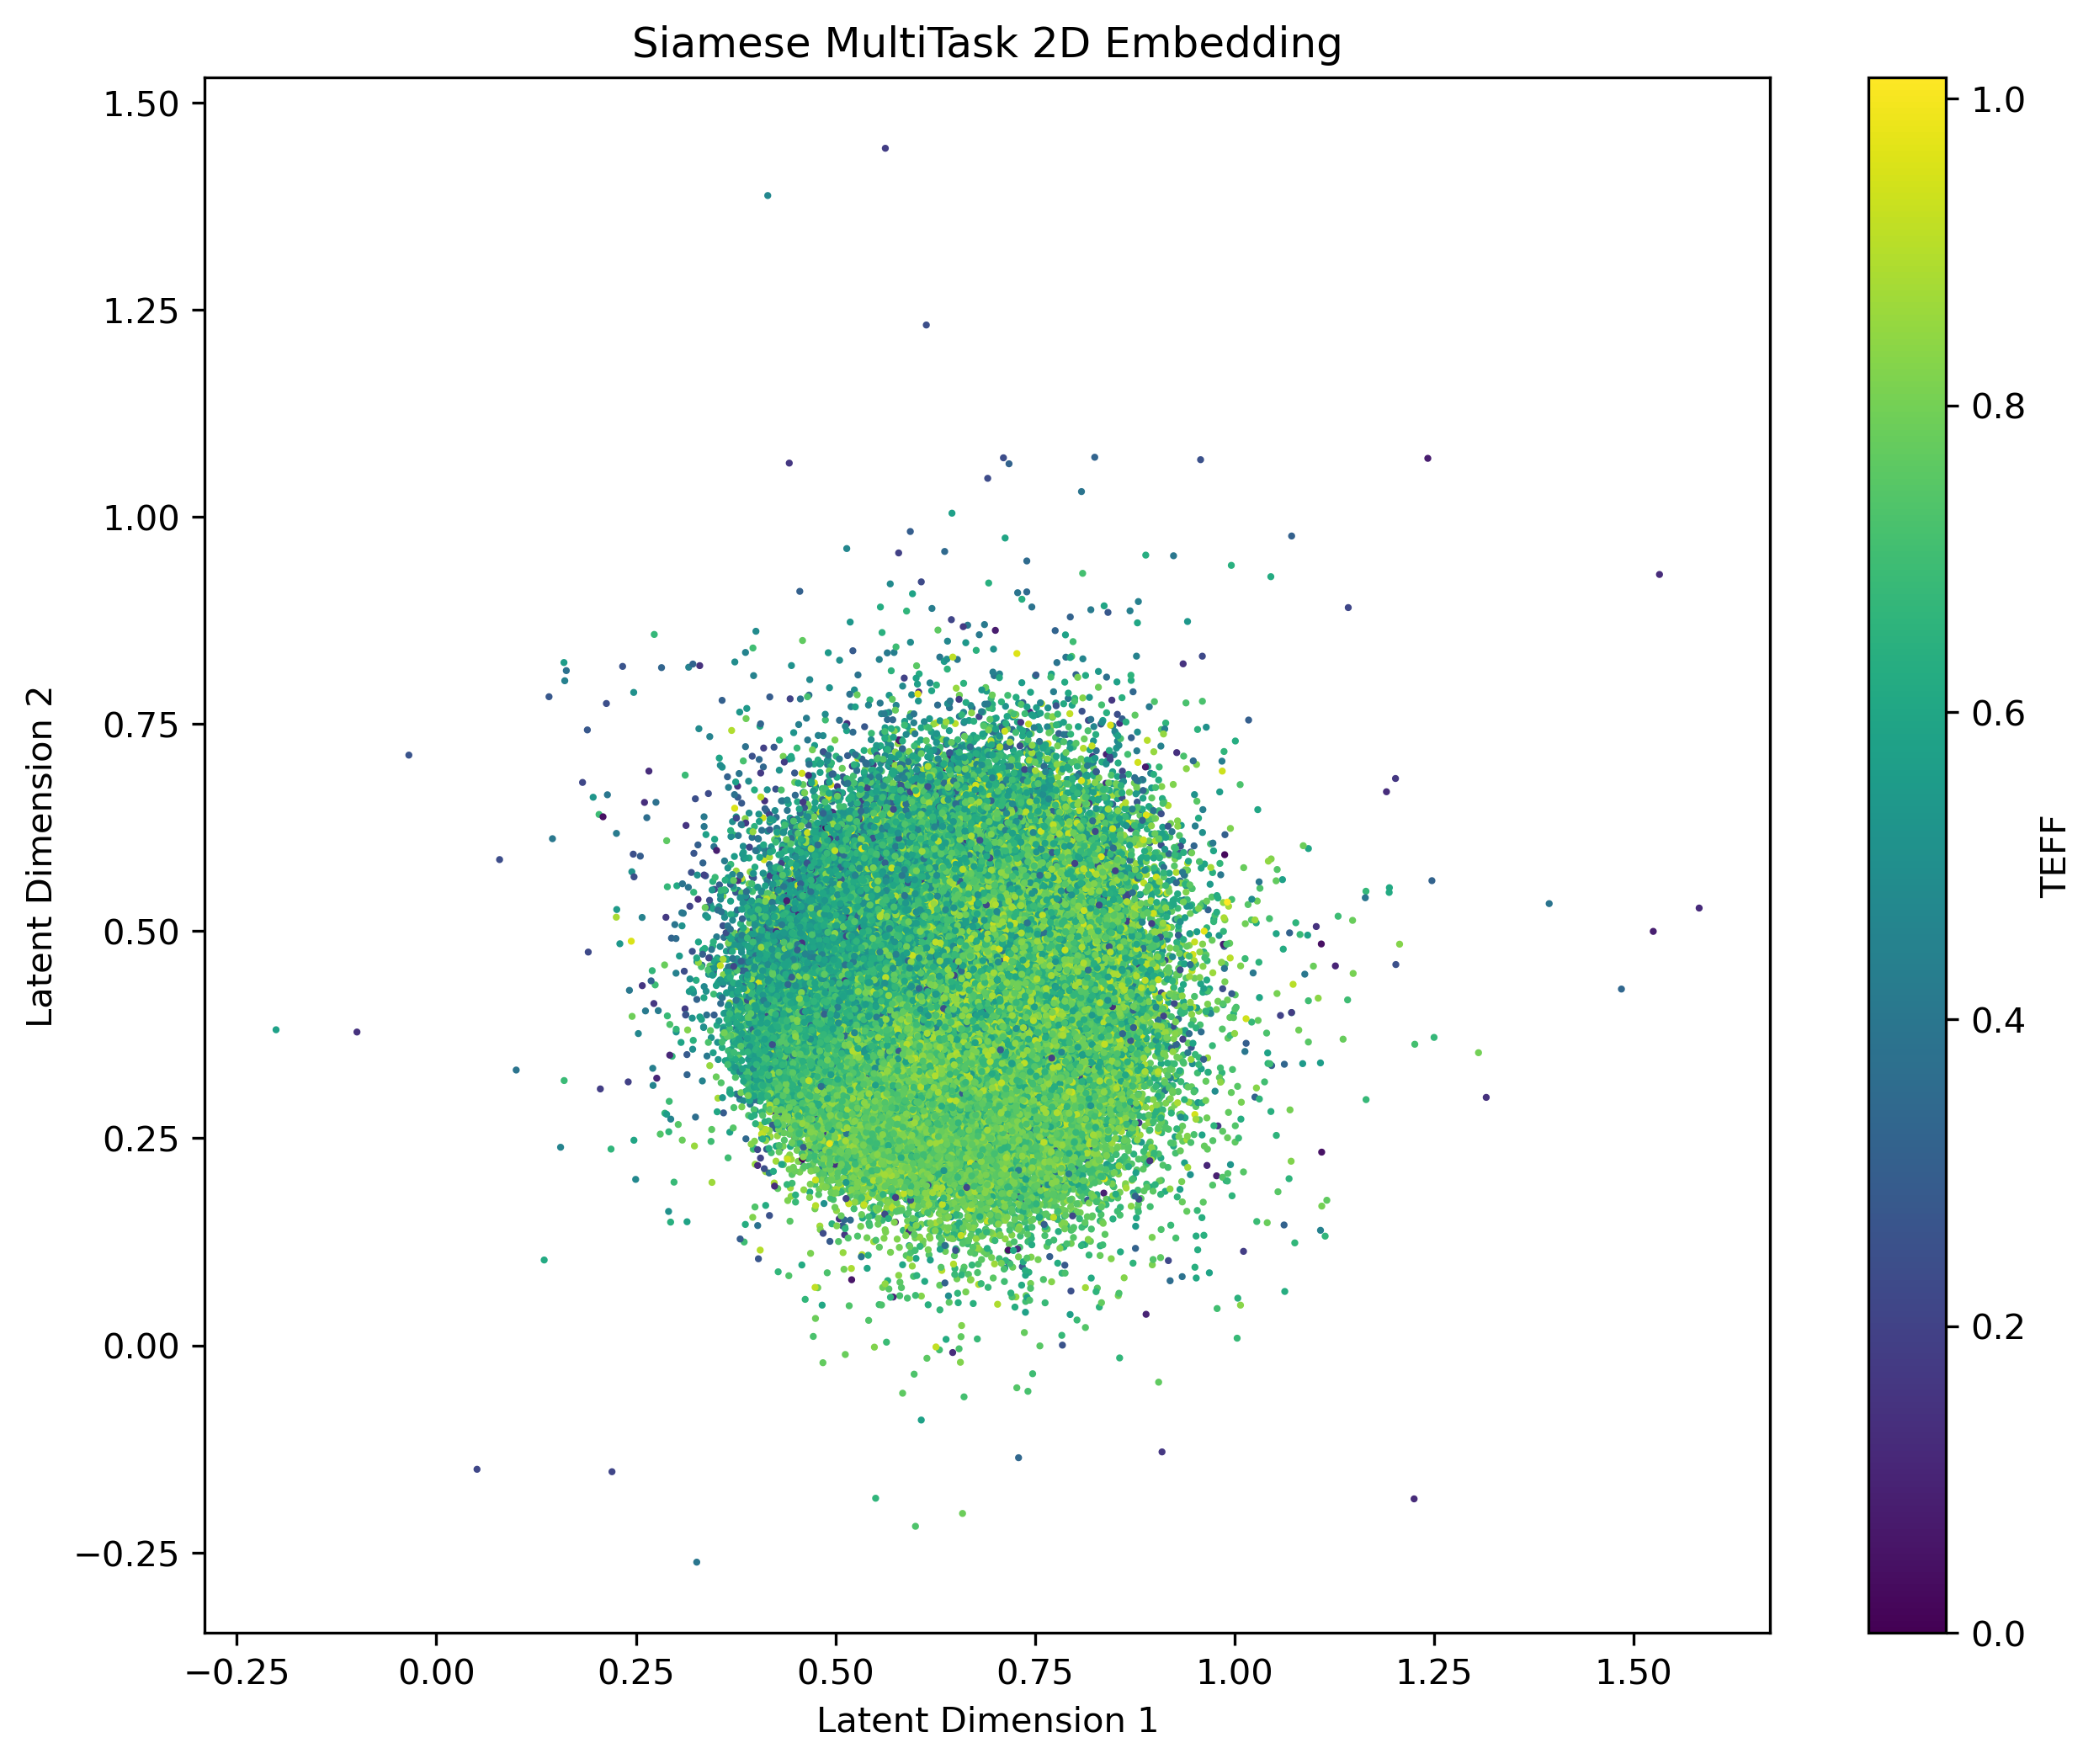

In [10]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weight_folder = "output_weight"
embedding_dims = [2]  # Nous travaillons ici avec un modèle 2D
input_dim = X_train.shape[1]  # Nombre de features chimiques en entrée

# Créer le modèle avec embedding_dim=2 et phys_out_dim correspondant au nombre de colonnes physiques (ici 5)
model = SiameseMultiTaskNetwork(input_dim=input_dim, embedding_dim=2, phys_out_dim=len(phys_columns)).to(device)

# Charger les poids du modèle entraîné
model_path = os.path.join(weight_folder, "siamese_multitask_model_triplet_2D.pth")
if not os.path.isfile(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Concaténer les features de train et test pour obtenir l'ensemble complet
X_all = torch.cat((X_train, X_test), dim=0).to(device)

# Forward pass pour obtenir les embeddings (on utilise forward_once pour obtenir uniquement l'embedding)
with torch.no_grad():
    z_all, _ = model.forward_once(X_all)  # z_all a la forme [N, 2]

# Convertir les embeddings en numpy array pour le plotting
embeddings = z_all.cpu().numpy()

# Récupérer la colonne TEFF pour le coloriage, en concaténant train_df et test_df
data_full = pd.concat([train_df, test_df], ignore_index=True)
color = data_full["FE_H"].values  # Vous pouvez choisir une autre variable de couleur

# Création du scatter plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
sc = ax.scatter(embeddings[:, 0], embeddings[:, 1], c=color, s=1.0, cmap='viridis')
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("Latent Dimension 1")
ax.set_ylabel("Latent Dimension 2")
ax.set_title("Siamese MultiTask 2D Embedding")
plt.show()


In [15]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, verbose=True)
z_2d_cupy = tsne.fit_transform(z_all_cupy)  # shape [N,2]
z_2d_cudf = cudf.DataFrame(z_2d_cupy, columns=["dim1", "dim2"])
z_2d_df = z_2d_cudf.to_pandas()


/home/maxime/miniforge3/envs/rapids-25.02/lib/python3.12/site-packages/cuml/internals/api_decorators.py:400: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[2025-03-29 09:38:44.678] [CUML] [debug] Learning rate is adaptive. In TSNE paper, it has been shown that as n->inf, Barnes Hut works well if n_neighbors->30, learning_rate->20000, early_exaggeration->24.
[2025-03-29 09:38:44.678] [CUML] [debug] cuML uses an adpative method.n_neighbors decreases to 30 as n->inf. Likewise for the other params.
[2025-03-29 09:38:44.678] [CUML] [debug] New n_neighbors = 30, learning_rate = 53802.0, exaggeration = 24.0
[2025-03-29 09:38:44.678] [CUML] [debug] Data size = (161406, 4) with dim = 2 perplexity = 30.000000
[2025-03-29 09:38:44.678] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
[2025-03-29 09:38:44.678] [CUML] [debug] Getting distances.
[2025-03-29 09:38:46.848] [CUML] [debug] Now normalizing distances so exp(D) doesn't explode.
[2025-03-29 09:38:46.849] [CUML] [debug] Searching for optimal perplexity via bisection search.
[2025-03-29 09:38:51.372] [CUML] [debug] [t-SNE] KL dive

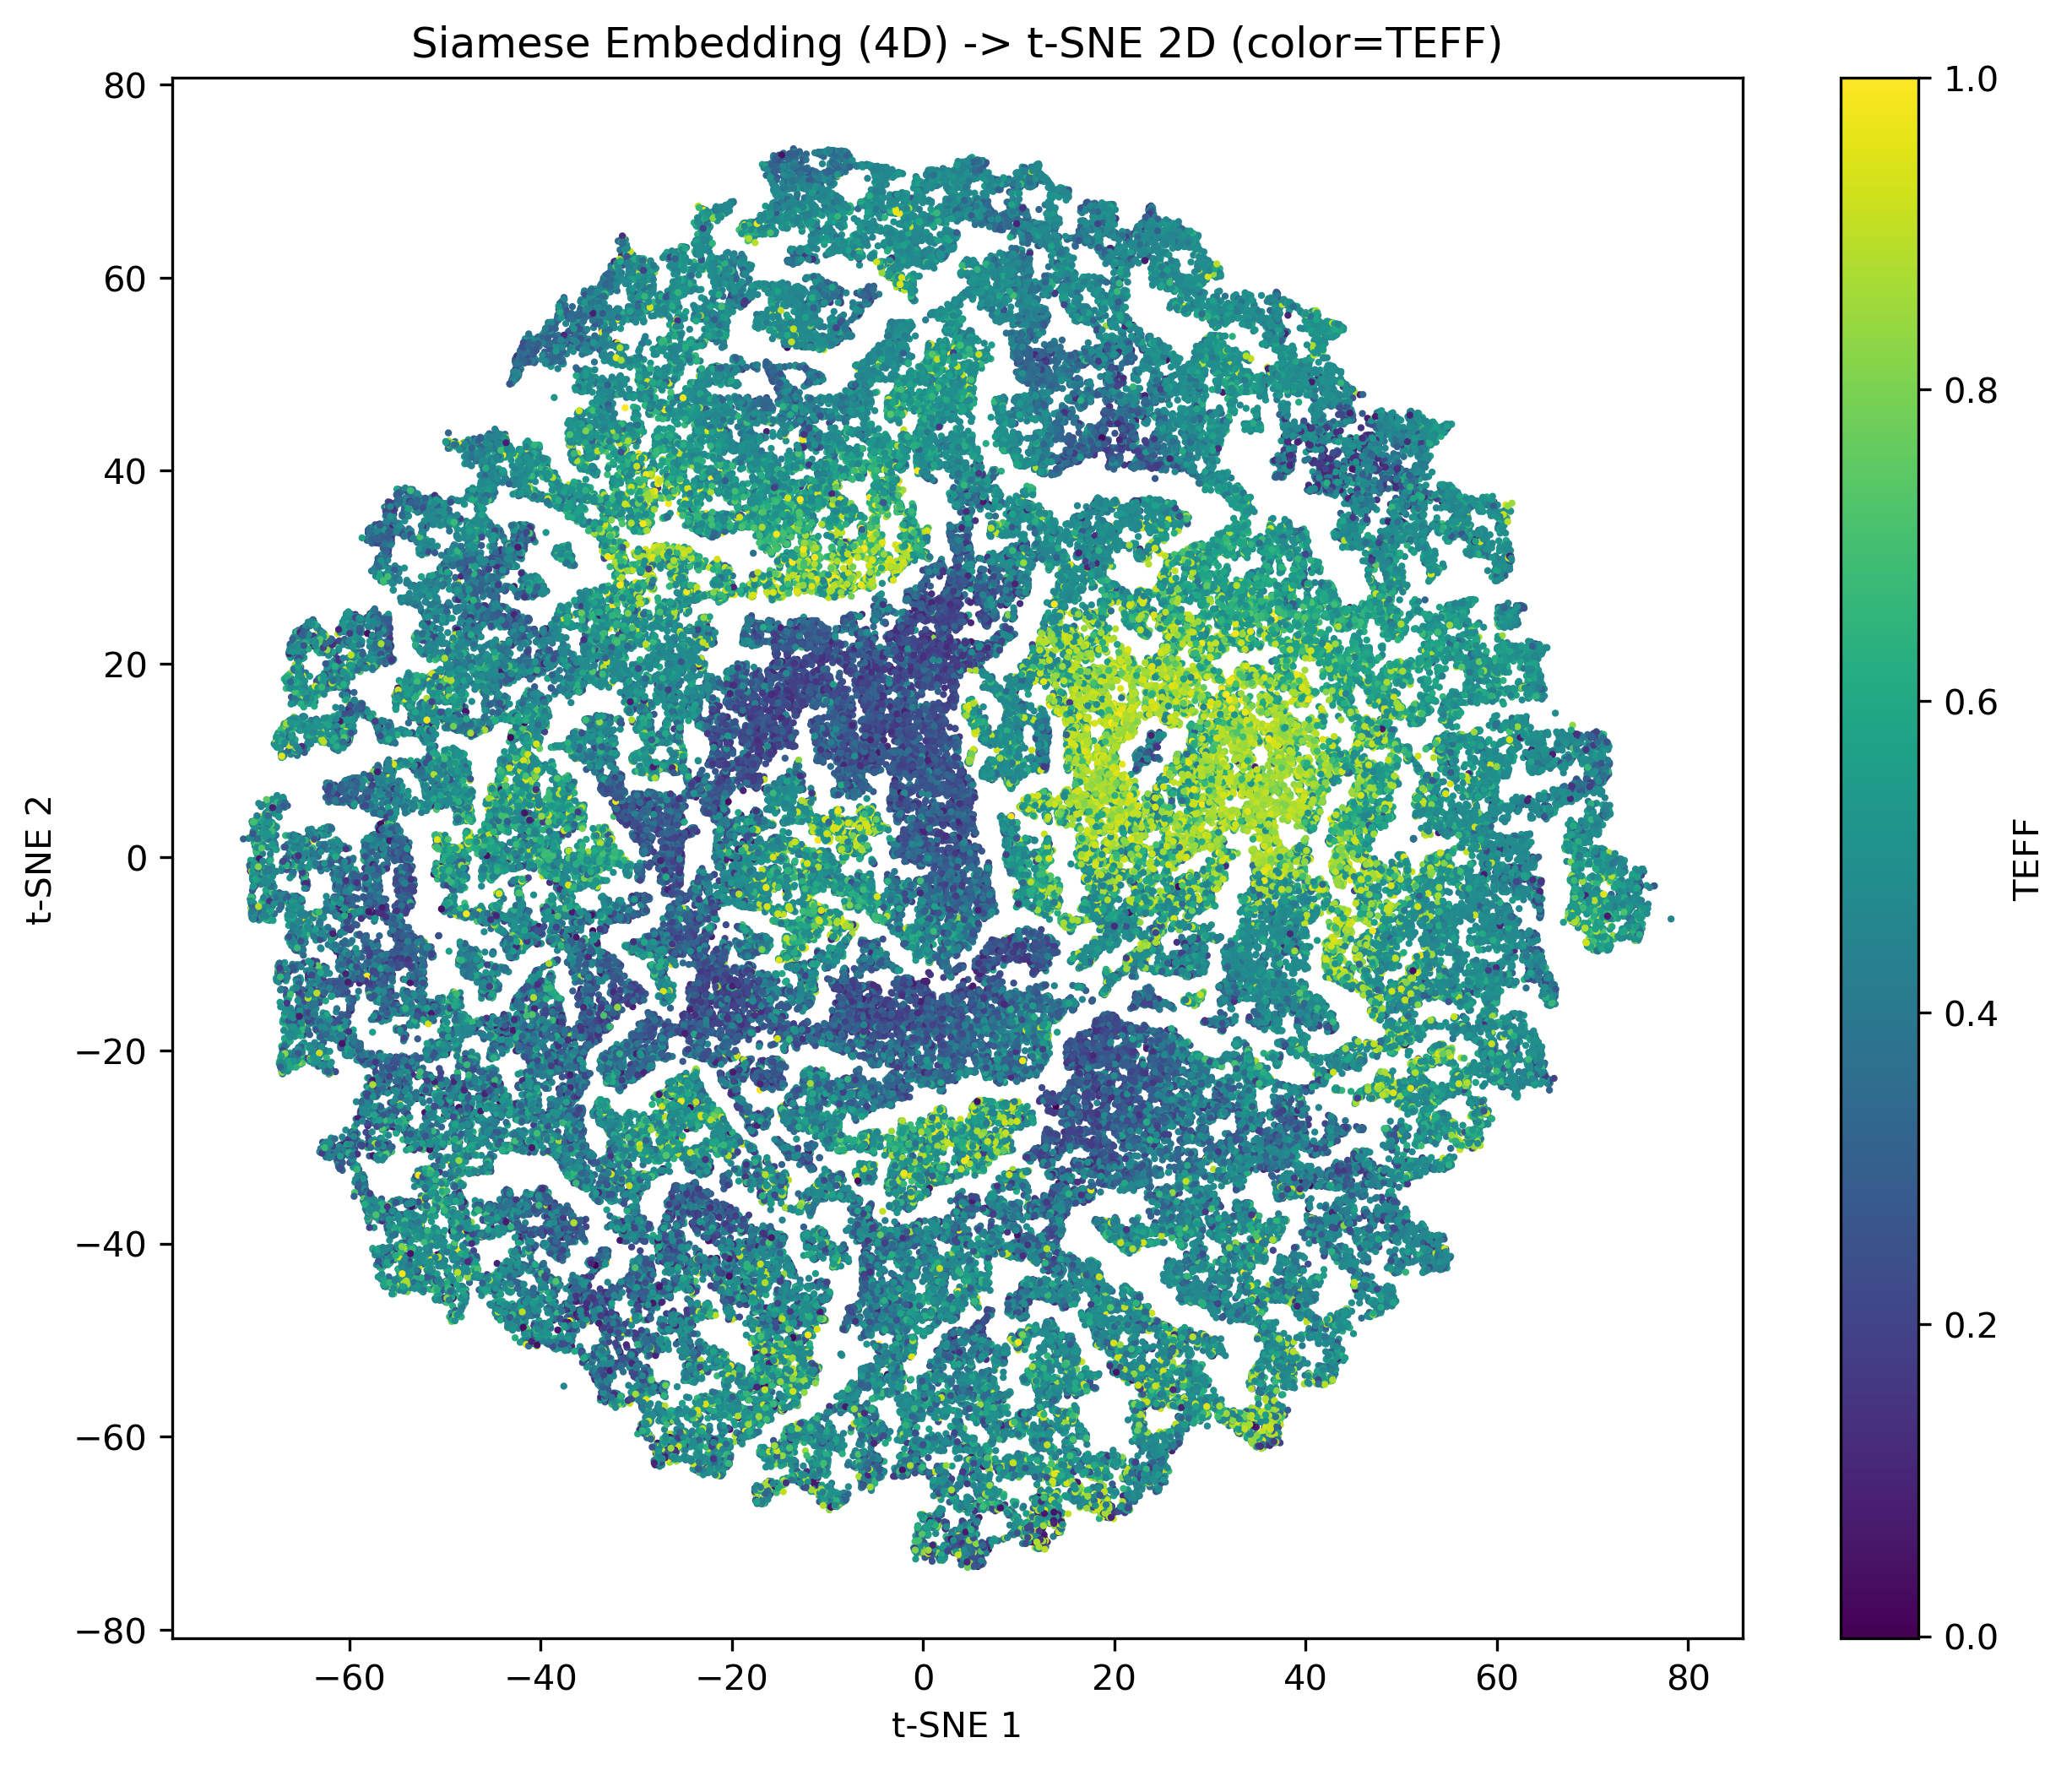

In [17]:
# Suppose we want the original TEFF from train+test concatenated

data = pd.concat([train_df, test_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                 s=1.0, cmap='viridis', c =data["LOGG"].values)
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("Siamese Embedding (4D) -> t-SNE 2D (color=TEFF)")
plt.show()


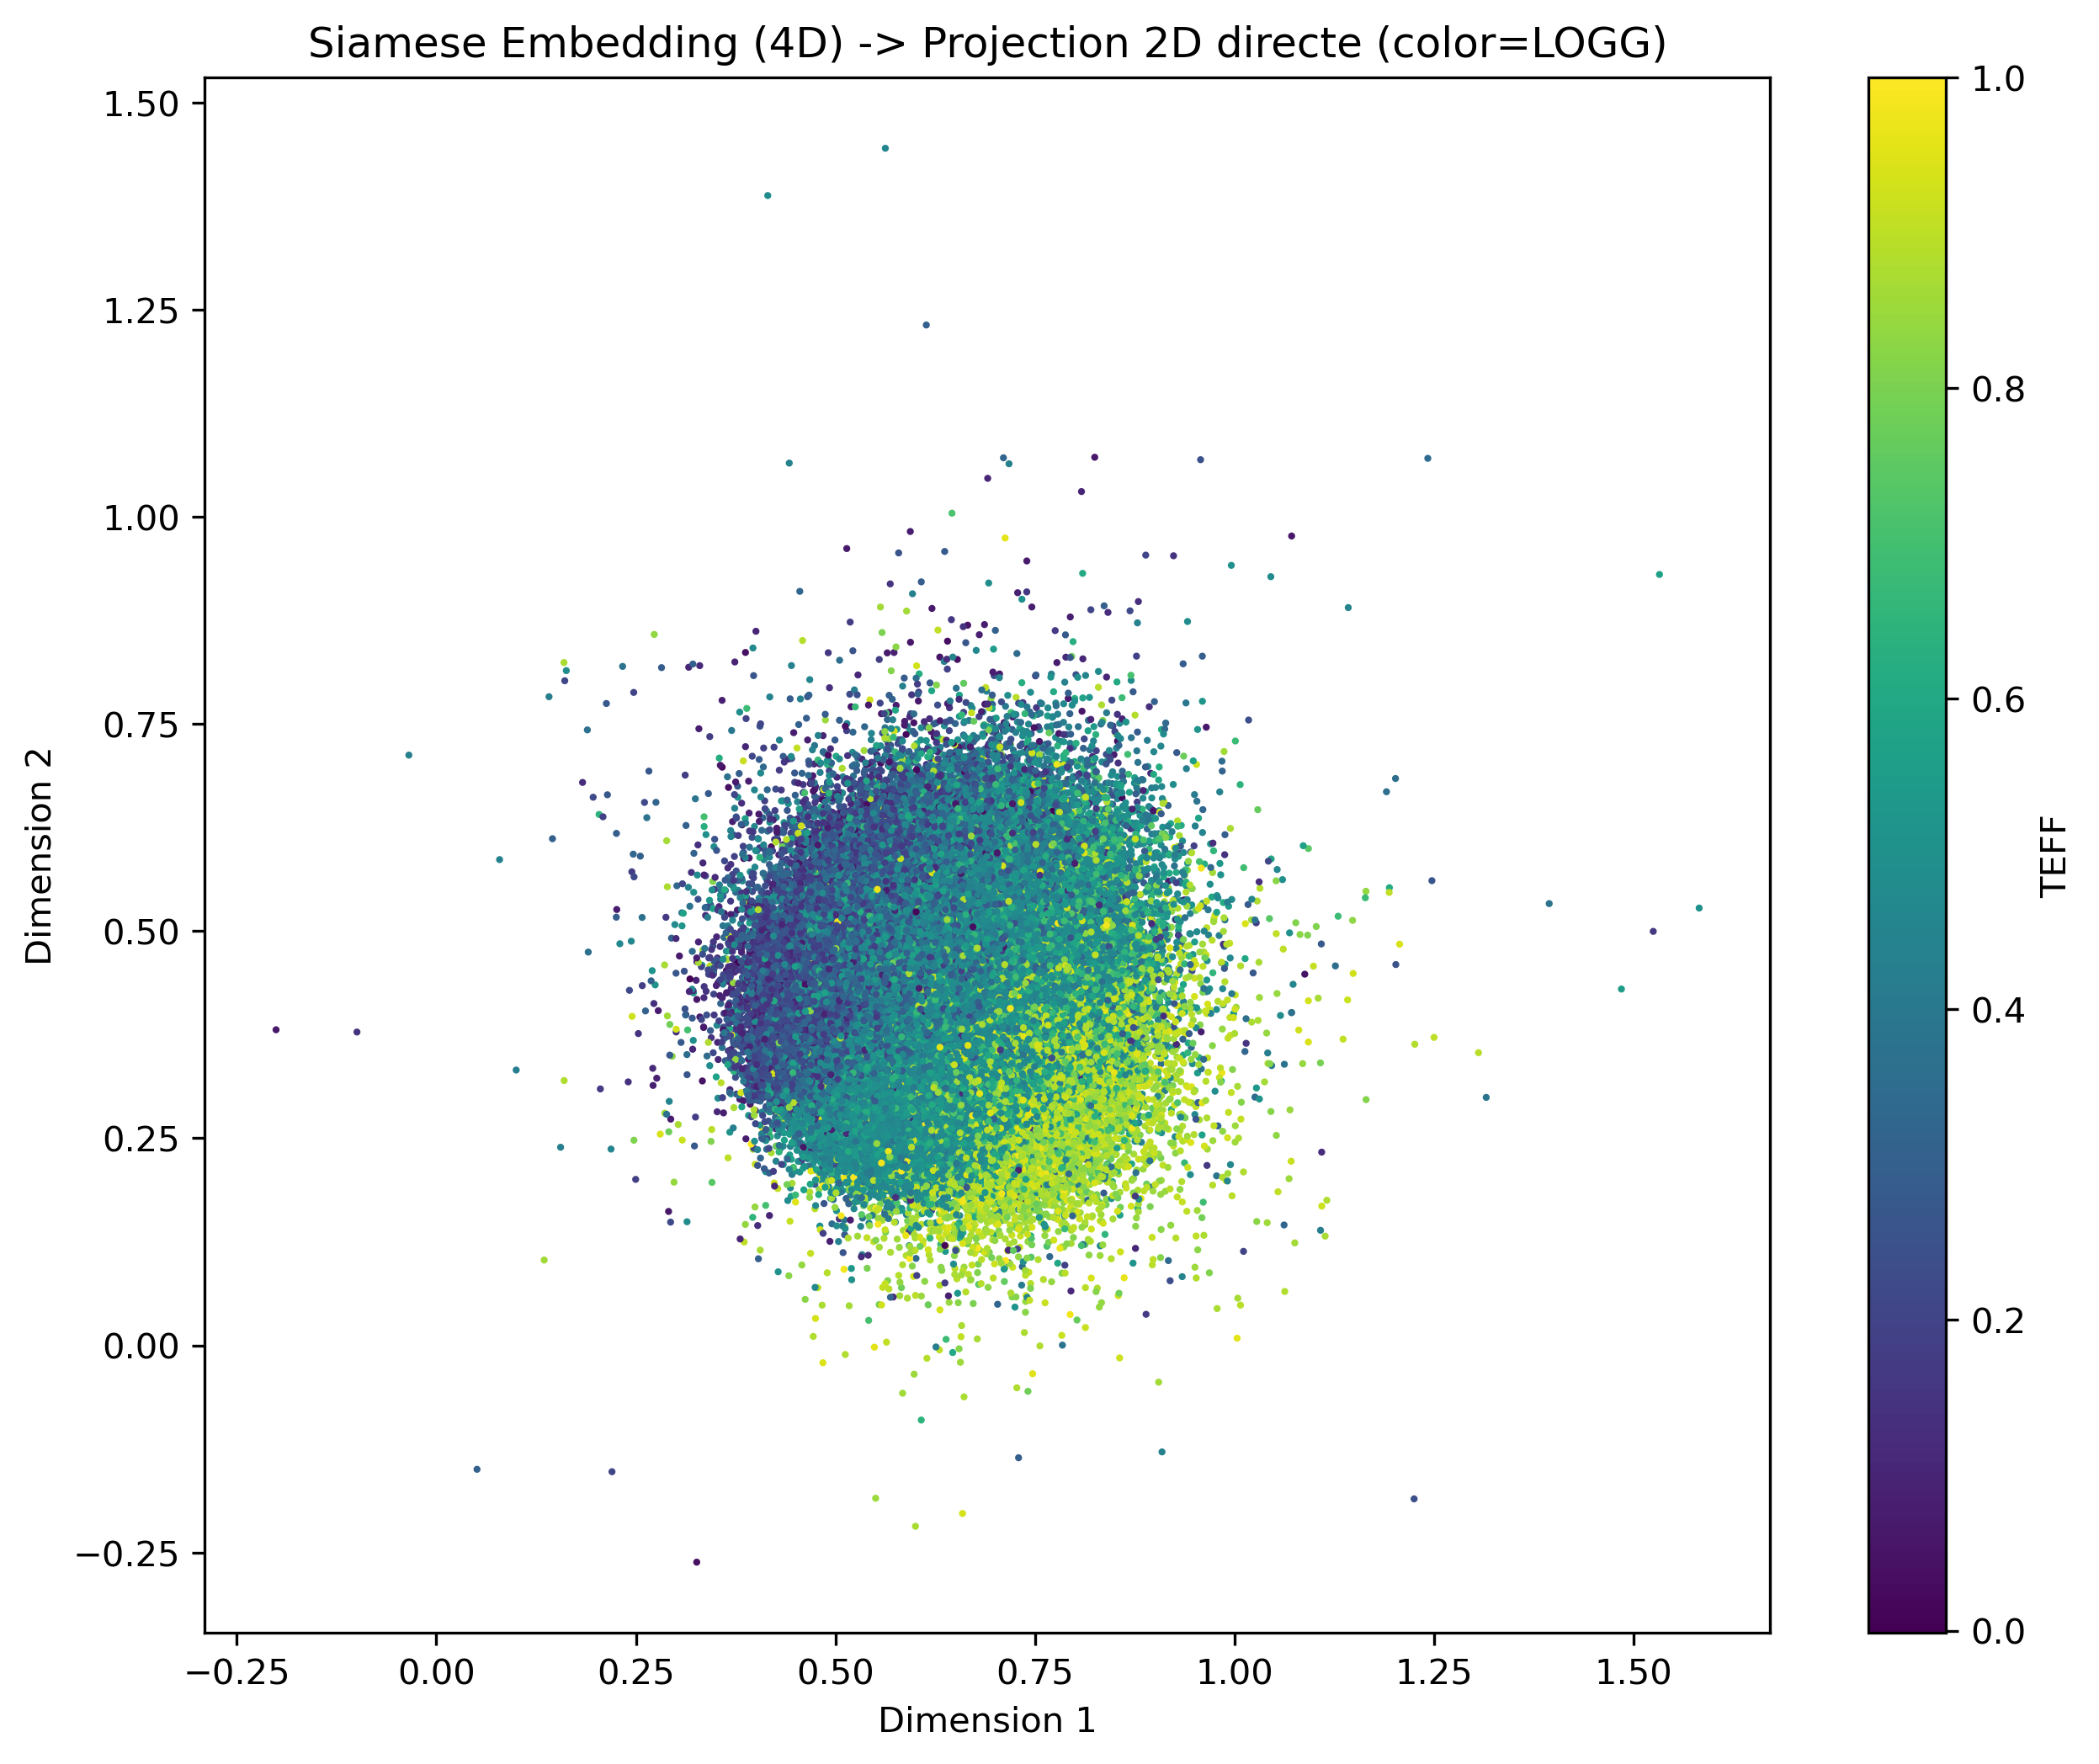

In [13]:
model.eval()
with torch.no_grad():
    # On concatène les données train et test et on les déplace sur le GPU
    X_all = torch.cat((X_train, X_test), dim=0).cuda()
    z_all, out_all = model.forward_once(X_all)  # z_all: [N, 4]

# Projection directe en 2D en sélectionnant les deux premières dimensions
z_2d_direct = z_all[:, :2].cpu().numpy()  # shape [N,2]

# Création d'un DataFrame pour faciliter le plotting (optionnel)
z_2d_df = pd.DataFrame(z_2d_direct, columns=["dim1", "dim2"])


# Plot
fig, ax = plt.subplots(figsize=(10,8), dpi=300)
sc = ax.scatter(z_2d_df["dim1"], z_2d_df["dim2"],
                c=data["LOGG"].values, s=1.0, cmap='viridis')
plt.colorbar(sc, label="TEFF")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Siamese Embedding (4D) -> Projection 2D directe (color=LOGG)")
plt.show()
